In [2]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
from create_engine import ENGINE

query = """
SELECT *
FROM IDS_DATA_FINALIZED
"""

df = pd.read_sql(query, ENGINE)

print(df.head())

2026-05-29 00:05:34,354 - INFO - Connection Built Successfully


Connecting to DB: localhost/cti_fyp
   protocol  flow duration  total fwd packet  total bwd packets  \
0         6       57185951               164                205   
1        17          30996                 1                  1   
2        17         130551                 1                  1   
3        17            173                 2                  2   
4         6      115455124                17                 16   

   total length of fwd packet  total length of bwd packet  \
0                     11307.0                    273722.0   
1                        57.0                        73.0   
2                        48.0                        64.0   
3                        90.0                       122.0   
4                      2129.0                       295.0   

   fwd packet length max  fwd packet length min  fwd packet length mean  \
0                 1159.0                    0.0               68.945122   
1                   57.0                   5

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
import joblib

In [46]:
model_load = joblib.load('encoder_Saved.joblib')

In [49]:
print(dict(enumerate(model_load.classes_))) 

{0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'PortScan', 10: 'SSH-Patator'}


## Label Distribution
#### Label Distribution of all the attacks

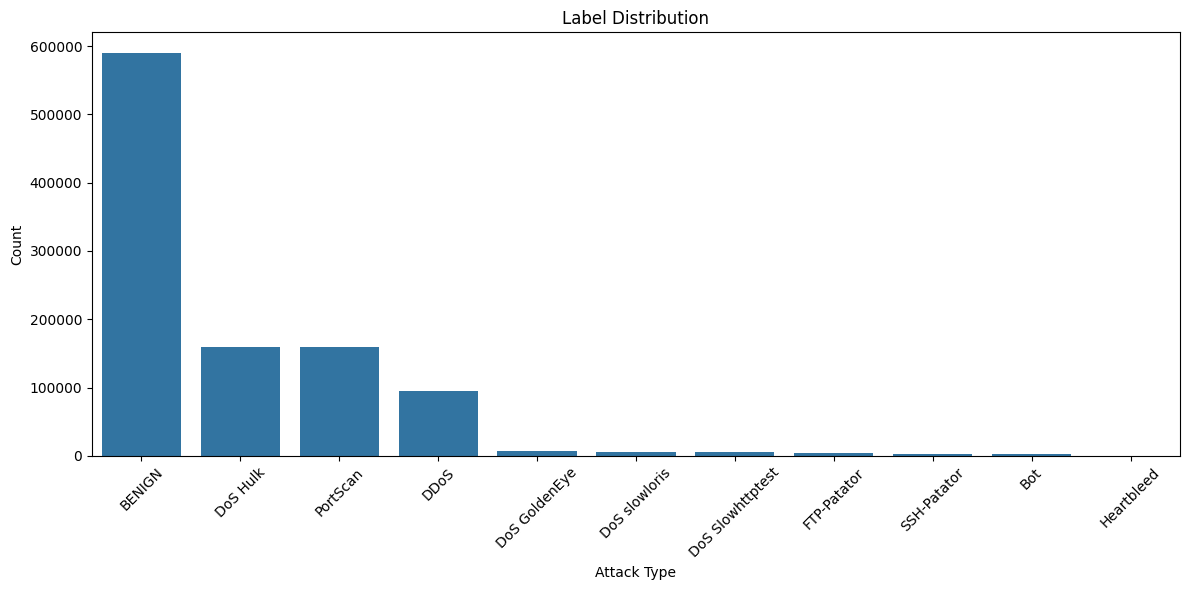

In [67]:
plt.figure(figsize=(12,6))
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.tight_layout()
plt.show()

## Pie chart of Attack vs BENIGN 
#### Attack vs BENIGN in percentages

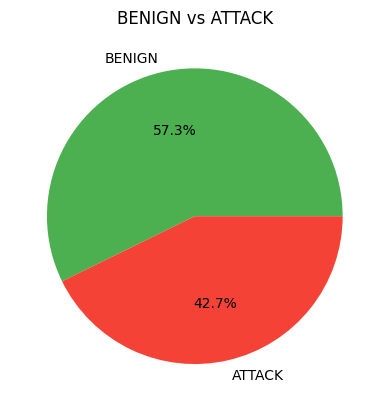

In [8]:
benign = (df['label'] == 0).sum()
attack = (df['label'] != 0).sum()

plt.pie(
    [benign, attack],
    labels=['BENIGN', 'ATTACK'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336']
)
plt.title('BENIGN vs ATTACK')
plt.show()

## Pie Chart
#### Pie chart showing different attacks along with their count and percentages

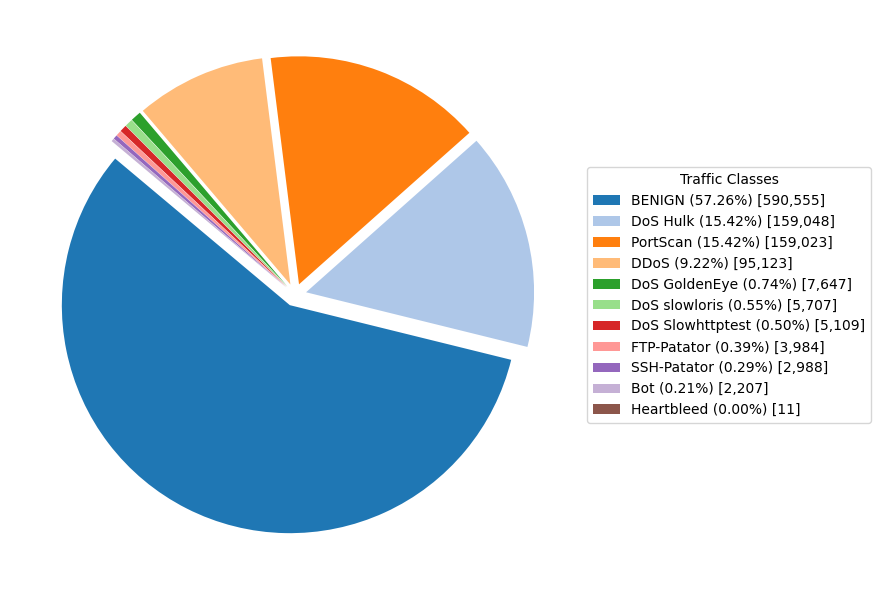

In [ ]:
df['label_name'] = model_load.inverse_transform(df['label'].astype(int))
label_counts = df['label_name'].value_counts()  
counts = df['label_name'].value_counts()         
percentages = df['label_name'].value_counts(normalize=True) * 100  

plt.figure(figsize=(12, 6))
colors = sns.color_palette('tab20', len(counts))
explode = [0.05] * len(counts)

wedges, _ = plt.pie(
    counts, 
    labels=None,       
    startangle=140, 
    colors=colors, 
    explode=explode
)

legend_labels = [
    f'{label} ({pct:.2f}%) [{count:,}]' 
    for label, pct, count in zip(counts.index, percentages, counts.values)
]

plt.legend(
    wedges, 
    legend_labels, 
    title="Traffic Classes", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

## Median Flow Duration By Label
#### Flow duration of different attacks

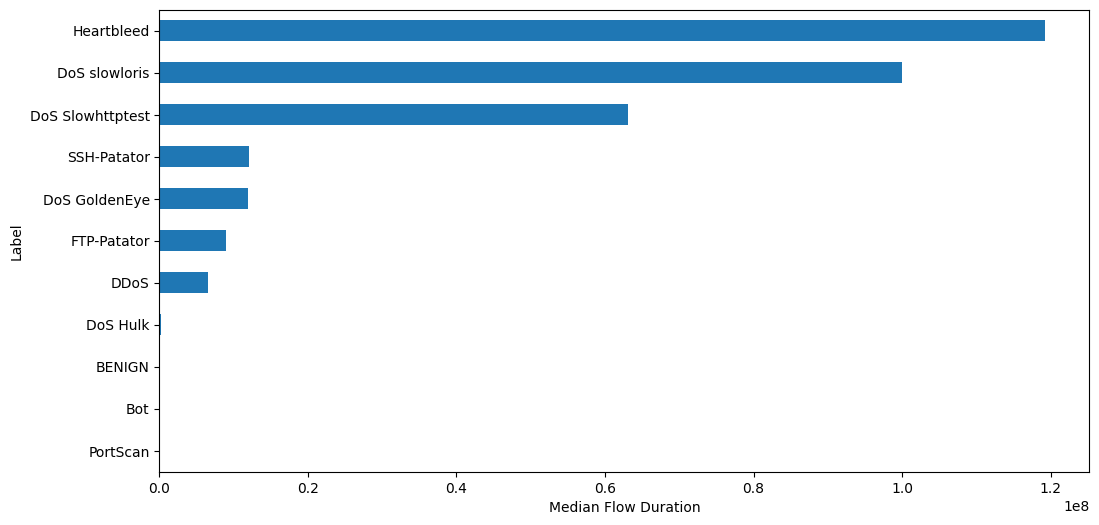

In [58]:
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
plt.figure(figsize=(12,6))
df.groupby('label_name')['flow duration'].median().sort_values().plot(kind='barh')  # ← groupby label_name directly
plt.xlabel('Median Flow Duration')
plt.ylabel('Label')
plt.show()

## Traffic UP/DOWN Ratio
#### Indicates the traffic up/down of different attacks

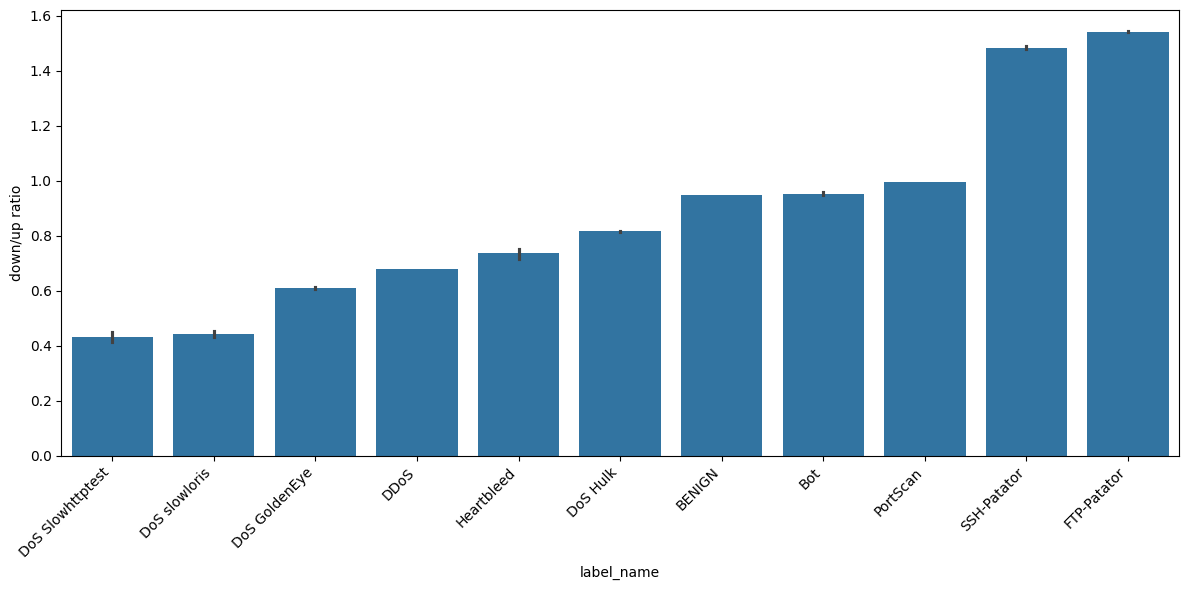

In [57]:
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
plt.figure(figsize=(12,6))
order = df.groupby('label_name')['down/up ratio'].median().sort_values().index
sns.barplot(data=df, x='label_name', y='down/up ratio', order=order) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap 

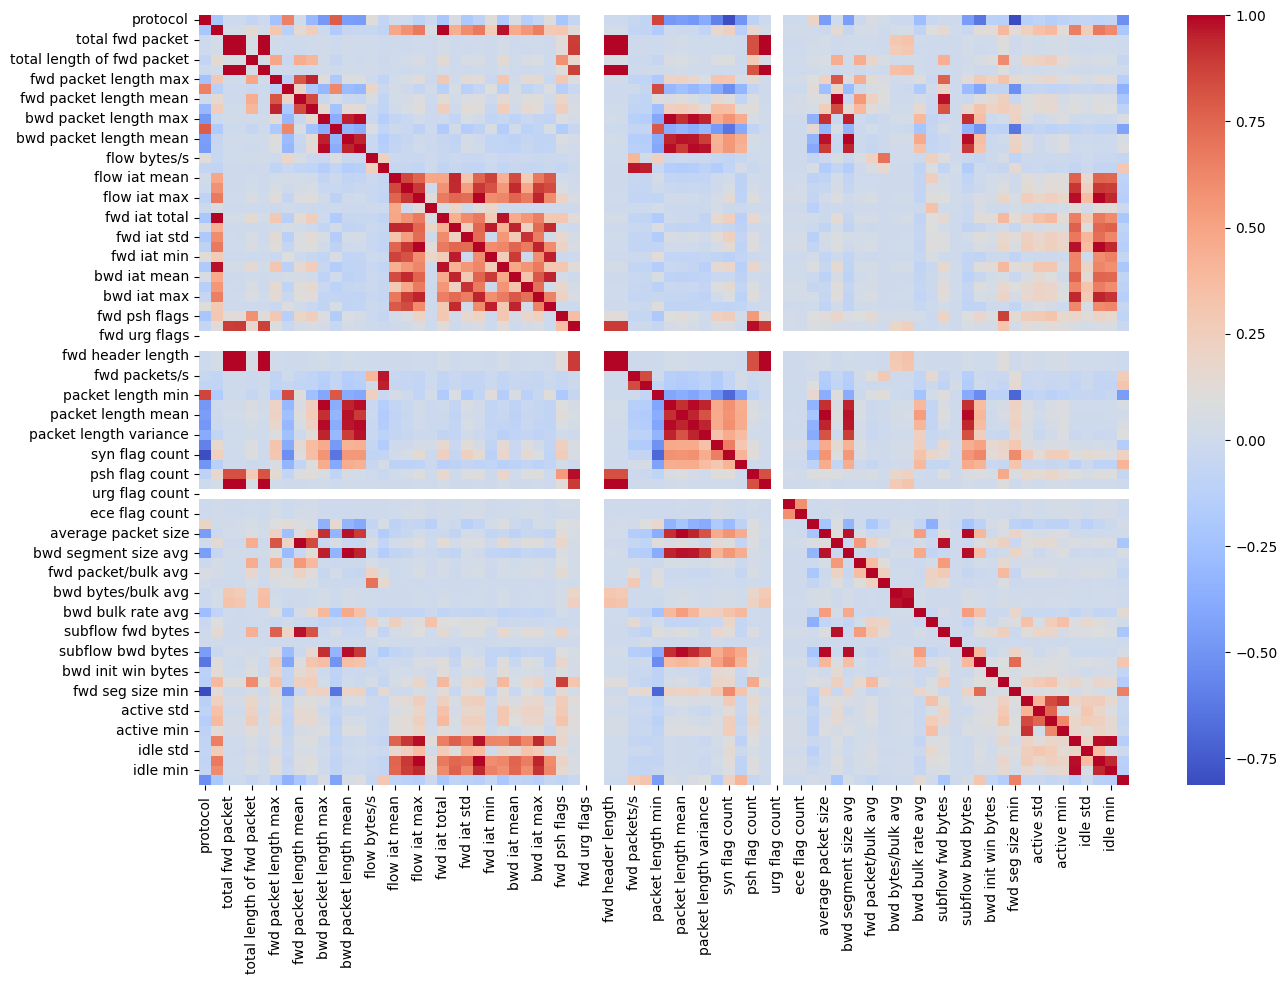

In [3]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Time Based Pairplot 
#### Shows the pairplot of the time based metrics in the dataset

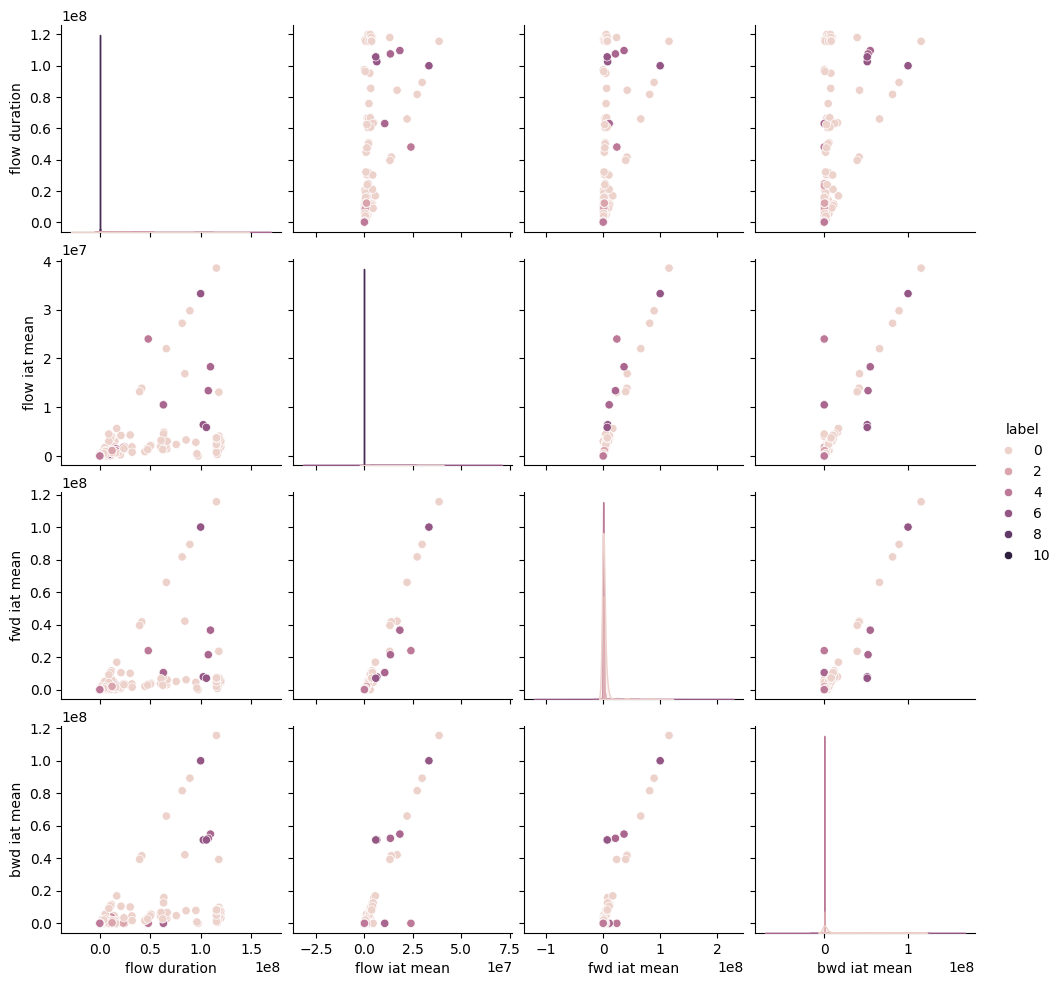

In [27]:
time_features = ['flow duration', 'flow iat mean', 'fwd iat mean', 'bwd iat mean', 'label']
sns.pairplot(df.sample(1000, random_state=42)[time_features], hue='label')

## Volumne Based Pairplot
#### Shows the pairplot of the volumne based metrics of packets in the dataset

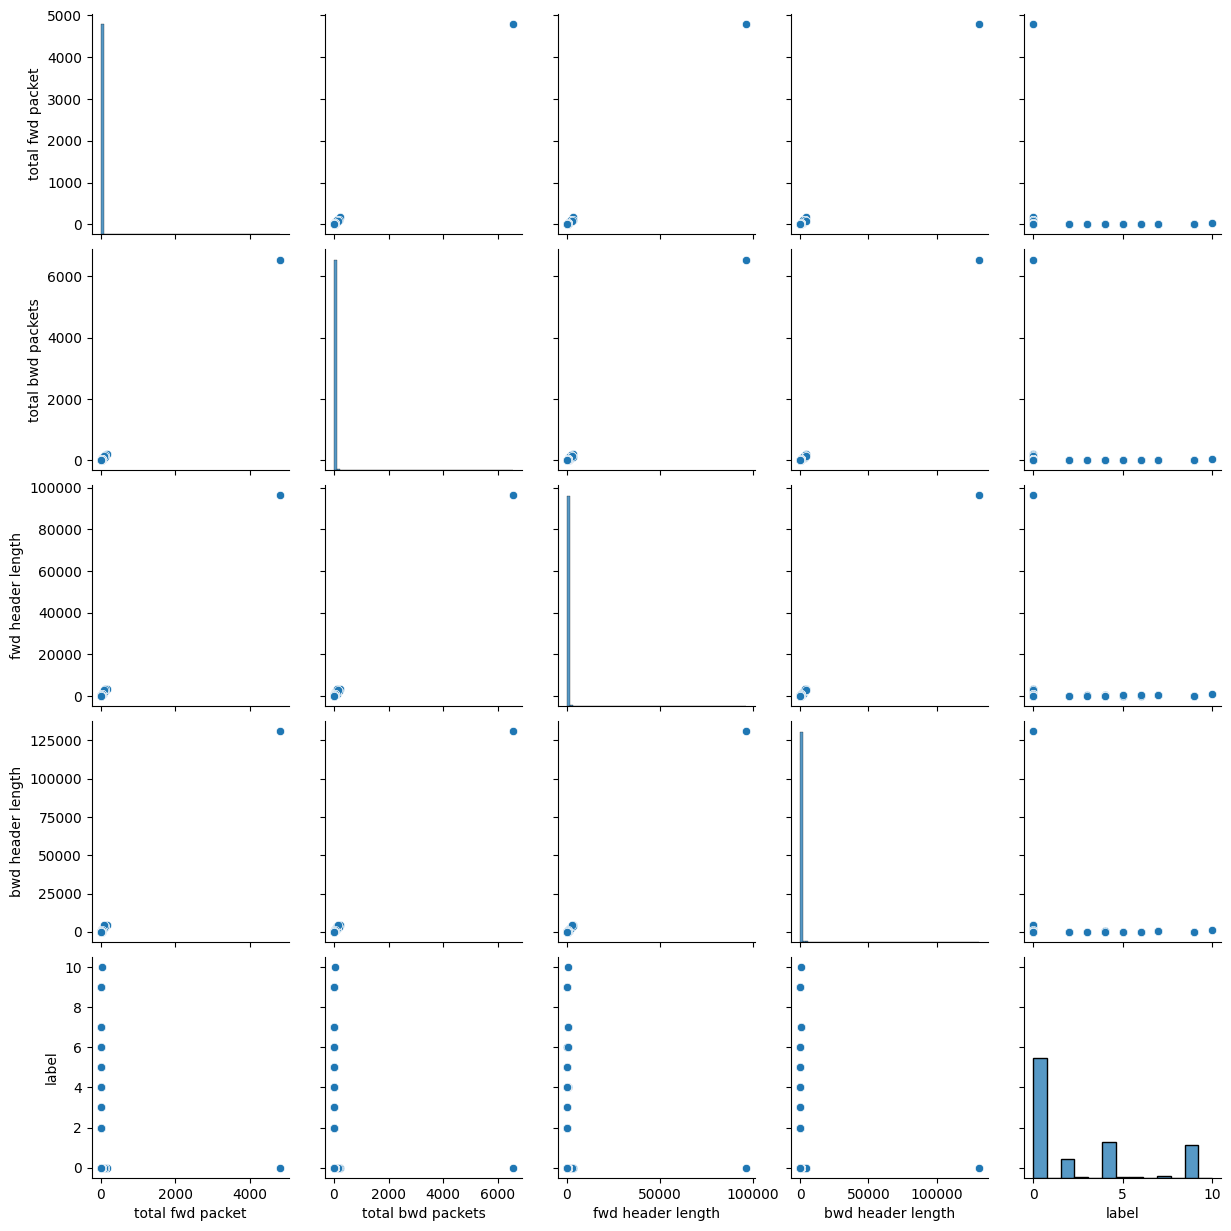

In [31]:
volume_features = ['total fwd packet', 'total bwd packets', 'fwd header length', 'bwd header length', 'label']
sns.pairplot(df.sample(1000, random_state=42)[volume_features])

## Pairplot of Packet Columns
#### Pairplot showing the min, max, mean, std of the length of packet

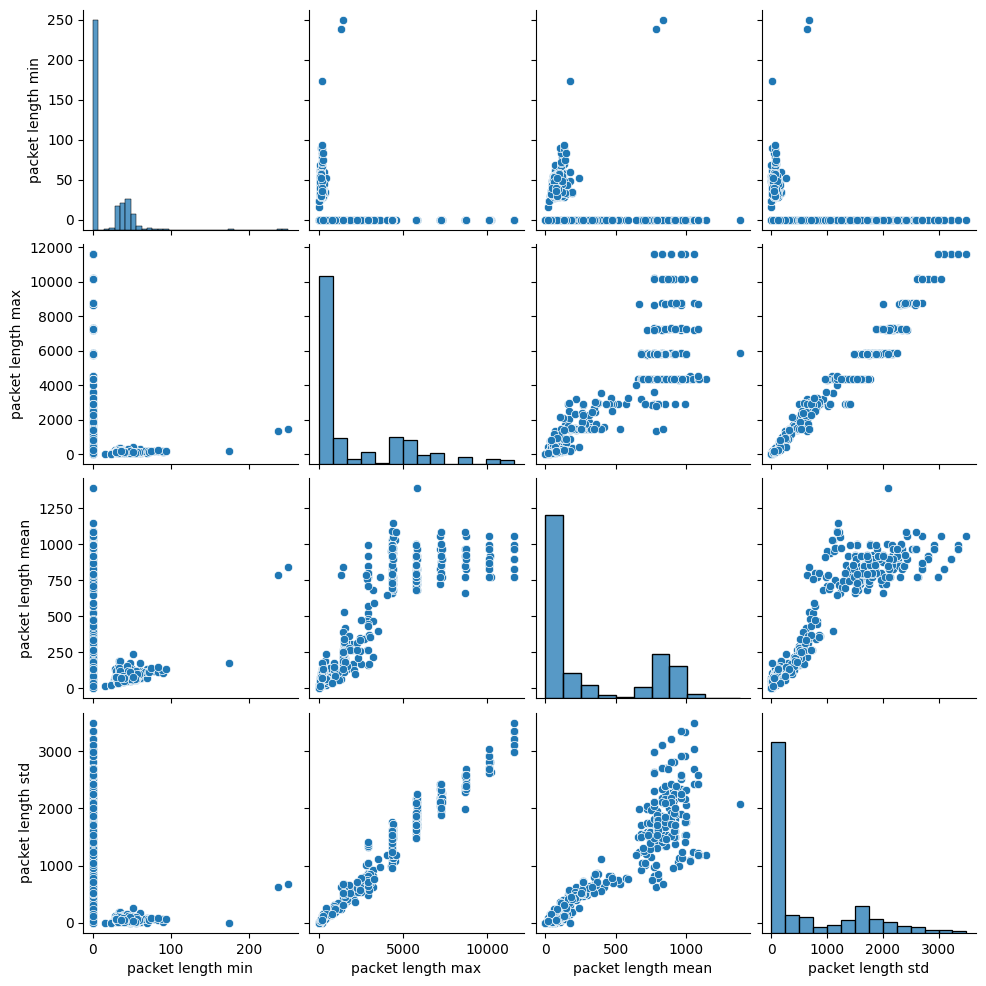

In [30]:
packet_cols = ['packet length min', 'packet length max', 'packet length mean', 'packet length std']
sns.pairplot(df.sample(1000, random_state=42)[packet_cols])